In [52]:
# ===========================================================================
# Cell 1 — Imports & data
# ===========================================================================
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Aligned daily realized-variance panel (built in CSVprocessing.ipynb)
data = pd.read_parquet("merged_RV_GVZ.parquet")

# Target series for the base-case HAR: gold realized variance only
rv = data["RV_gold"].astype(float)
print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"strictly positive: {(rv > 0).all()}  (required for QLIKE and log)")
rv.describe()


RV_gold: 4114 obs, 2010-01-04 .. 2026-05-29
strictly positive: True  (required for QLIKE and log)


count    4114
mean    14.54
std     6.895
min     4.904
25%     10.39
50%     13.04
75%     16.75
max       101
Name: RV_gold, dtype: float64

                  n  skewness  excess_kurtosis   JB_stat  JB_pvalue  normal_at_5%
series                                                                           
RV_gold (raw)  4114     3.642            27.04 1.344e+05          0         False
log(RV_gold)   4114    0.7012            1.374     660.5 3.684e-144         False

Interpretation: raw RV_gold rejects normality (JB p=0.00e+00); log(RV_gold) rejects normality (JB p=3.68e-144). Logging sharply reduces skewness/kurtosis toward the normal benchmark.


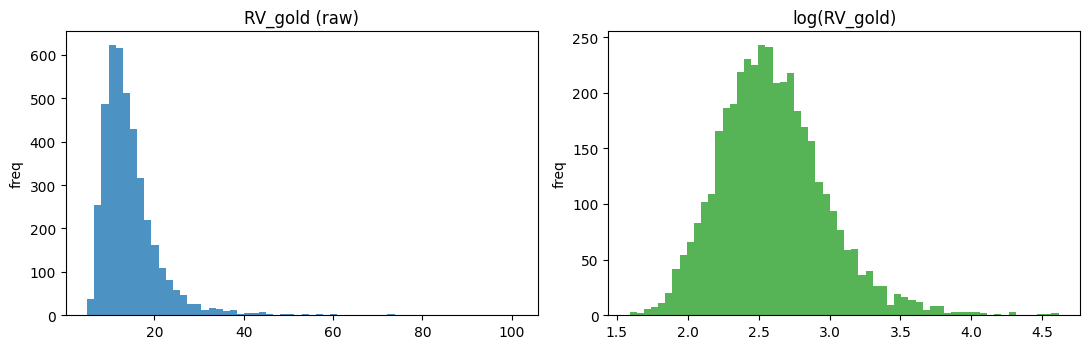

In [53]:
# ===========================================================================
# Cell 2 — Normality analysis of gold RV: raw vs log  (Jarque-Bera, skew, kurt)
# ===========================================================================
# RV is known to be highly right-skewed and leptokurtic; the log transform is
# the standard remedy. Document both with the Jarque-Bera test plus the moments
# that drive it (skewness and EXCESS kurtosis -> both 0 under normality).

def normality_report(x, label):
    x = np.asarray(x, dtype=float)
    jb_stat, jb_p = stats.jarque_bera(x)
    return {
        "series": label,
        "n": x.size,
        "skewness": stats.skew(x),
        "excess_kurtosis": stats.kurtosis(x),     # Fisher: 0 == normal
        "JB_stat": jb_stat,
        "JB_pvalue": jb_p,
        "normal_at_5%": jb_p > 0.05,
    }

log_rv = np.log(rv)

norm_table = pd.DataFrame([
    normality_report(rv,     "RV_gold (raw)"),
    normality_report(log_rv, "log(RV_gold)"),
]).set_index("series")

pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(norm_table.to_string())

raw_p, log_p = norm_table.loc["RV_gold (raw)", "JB_pvalue"], norm_table.loc["log(RV_gold)", "JB_pvalue"]
print(
    f"\nInterpretation: raw RV_gold {'rejects' if raw_p < 0.05 else 'does not reject'} normality "
    f"(JB p={raw_p:.2e}); log(RV_gold) {'rejects' if log_p < 0.05 else 'does not reject'} normality "
    f"(JB p={log_p:.2e}). Logging sharply reduces skewness/kurtosis toward the normal benchmark."
)

# Side-by-side histograms
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(rv, bins=60, color="tab:blue", alpha=0.8);  ax[0].set_title("RV_gold (raw)")
ax[1].hist(log_rv, bins=60, color="tab:green", alpha=0.8); ax[1].set_title("log(RV_gold)")
for a in ax: a.set_ylabel("freq")
plt.tight_layout(); plt.show()


In [54]:
# ===========================================================================
# Cell 3 — Build HAR (Corsi 2009) predictors and the 1-day-ahead target
# ===========================================================================
# Predictors known at day t (levels, base case uses gold RV's own history):
#   daily   RV_d[t] = RV_t
#   weekly  RV_w[t] = mean(RV_{t-4..t})    (5-day average)
#   monthly RV_m[t] = mean(RV_{t-21..t})   (22-day average)
# Regression target is next-day RV: y[t] = RV_{t+1}.

har = pd.DataFrame(index=rv.index)
har["RV_d"] = rv
har["RV_w"] = rv.rolling(5).mean()
har["RV_m"] = rv.rolling(22).mean()
har["y"]    = rv.shift(-1)            # one-day-ahead target

# Drop the 21-row monthly warm-up (leading NaNs) and the final row (no t+1 target)
har = har.dropna()

print(f"Usable (X, y) rows: {len(har)}")
print(f"Range: {har.index.min().date()} .. {har.index.max().date()}")
har.head()


Usable (X, y) rows: 4092
Range: 2010-02-03 .. 2026-05-28


,RV_d,RV_w,RV_m,y
Date,,,,
2010-02-03,17.3,19.78,18.99,35.89
2010-02-04,35.89,22.59,19.84,31.34
2010-02-05,31.34,24.61,20.47,18.39
2010-02-08,18.39,24.38,20.51,18.92
2010-02-09,18.92,24.37,20.67,22.74


In [55]:
# ===========================================================================
# Cell 4 — Rolling 1-day-ahead forecasts: direct closed-form OLS per window
# ===========================================================================
# Fixed 500-day rolling estimation window. Plain OLS is closed-form, so each
# step just re-solves the normal equations on its own window (no warm start).

WINDOW = 500

# Design matrix with intercept; rows aligned to `har`.
X_all = np.column_stack([np.ones(len(har)), har[["RV_d", "RV_w", "RV_m"]].to_numpy()])
y_all = har["y"].to_numpy()
dates = har.index

records = []
for t in range(WINDOW, len(har)):
    Xw = X_all[t - WINDOW:t]          # trailing 500 complete (X, y) pairs
    yw = y_all[t - WINDOW:t]
    beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)   # OLS coefficients
    fcast = X_all[t] @ beta           # forecast of RV_{t+1} from features at day t
    # dates[t] = forecast origin (day t); actual y_all[t] = realized RV one day later
    records.append((dates[t], y_all[t], fcast))

results = pd.DataFrame(records, columns=["origin_date", "actual", "forecast"]).set_index("origin_date")

print(f"Out-of-sample forecasts: {len(results)}")
print(f"OOS origin range: {results.index.min().date()} .. {results.index.max().date()}")
results.head()


Out-of-sample forecasts: 3592
OOS origin range: 2012-02-08 .. 2026-05-28


,actual,forecast
origin_date,,
2012-02-08,17.41,15.82
2012-02-09,17.76,16.7
2012-02-10,12.45,16.86
2012-02-13,15.31,14.03
2012-02-14,13.33,15.5


In [56]:
# ===========================================================================
# Cell 5 — QLIKE loss (Patton 2011, robust form)
# ===========================================================================
#   QLIKE = actual/forecast - log(actual/forecast) - 1   (>= 0, = 0 iff equal)
# Floor non-positive forecasts at eps so the log is defined (count clipped).
EPS = 1e-6

f = results["forecast"].to_numpy()
a = results["actual"].to_numpy()

n_clipped = int((f <= 0).sum())
f_safe = np.maximum(f, EPS)

ratio = a / f_safe
results["qlike"] = ratio - np.log(ratio) - 1.0

avg_qlike = results["qlike"].mean()

print(f"Forecasts clipped to eps={EPS:g}: {n_clipped}")
print(f"All per-day QLIKE >= 0: {(results['qlike'] >= 0).all()}")
print(f"\n>>> Average QLIKE (base-case simple HAR, 500-day rolling, 1-day-ahead): {avg_qlike:.6f}")


Forecasts clipped to eps=1e-06: 0
All per-day QLIKE >= 0: True

>>> Average QLIKE (base-case simple HAR, 500-day rolling, 1-day-ahead): 0.034304


             model: Base HAR-RV (Corsi 2009), levels, own d/w/m lags
        estimation: rolling 500-day window, direct OLS, 1-day-ahead
       n_forecasts: 3592
         oos_start: 2012-02-08
           oos_end: 2026-05-28
 forecasts_clipped: 0
         avg_QLIKE: 0.034304
      median_QLIKE: 0.013303

Spot-check OK: independent refit of final window reproduces last forecast (21.4761).


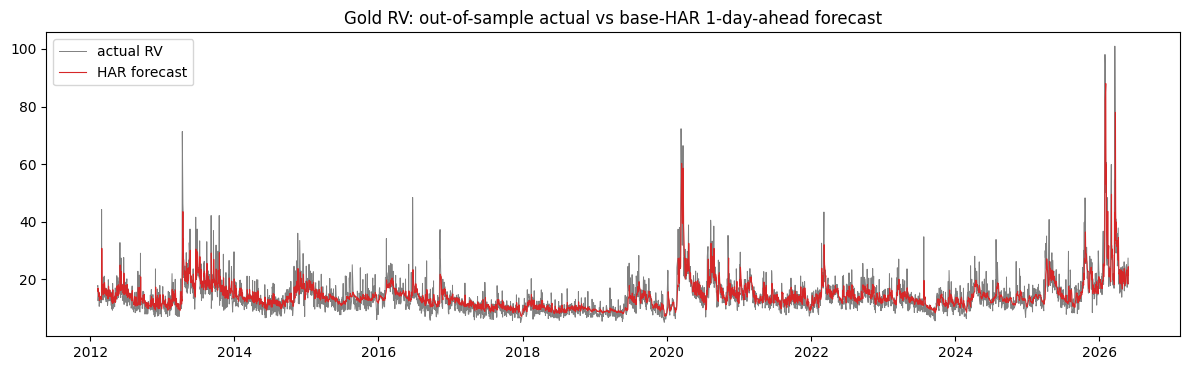

,actual,forecast,qlike
origin_date,,,
2012-02-08,17.41,15.82,0.004753
2012-02-09,17.76,16.7,0.001925
2012-02-10,12.45,16.86,0.0418
2012-02-13,15.31,14.03,0.003964
2012-02-14,13.33,15.5,0.01084


In [57]:
# ===========================================================================
# Cell 6 — Report & sanity checks
# ===========================================================================
summary = {
    "model": "Base HAR-RV (Corsi 2009), levels, own d/w/m lags",
    "estimation": "rolling 500-day window, direct OLS, 1-day-ahead",
    "n_forecasts": len(results),
    "oos_start": results.index.min().date(),
    "oos_end": results.index.max().date(),
    "forecasts_clipped": n_clipped,
    "avg_QLIKE": round(avg_qlike, 6),
    "median_QLIKE": round(results["qlike"].median(), 6),
}
for k, v in summary.items():
    print(f"{k:>18}: {v}")

# Spot-check: refit OLS directly on the final window and confirm last forecast matches
t = len(har) - 1
beta_chk, *_ = np.linalg.lstsq(X_all[t - WINDOW:t], y_all[t - WINDOW:t], rcond=None)
chk = X_all[t] @ beta_chk
assert np.isclose(chk, results["forecast"].iloc[-1]), "final-window refit mismatch"
print(f"\nSpot-check OK: independent refit of final window reproduces last forecast ({chk:.4f}).")

# Actual vs forecast over the out-of-sample period
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(results.index, results["actual"], lw=0.7, label="actual RV", color="0.5")
ax.plot(results.index, results["forecast"], lw=0.8, label="HAR forecast", color="tab:red")
ax.set_title("Gold RV: out-of-sample actual vs base-HAR 1-day-ahead forecast")
ax.legend(); plt.tight_layout(); plt.show()

results.head()


In [58]:
# ===========================================================================
# Cell 7 — log-HAR design table (mean-of-logs specification)
# ===========================================================================
# x = log(RV_gold). HAR components are built on the LOGGED series:
#   daily   x_d[t] = x_t
#   weekly  x_w[t] = mean(x_{t-4..t})
#   monthly x_m[t] = mean(x_{t-21..t})
# Target y_log[t] = x_{t+1} = log(RV_{t+1}). Keep the actual RV level (RV_{t+1})
# aligned for QLIKE, which is always evaluated in variance levels.

x = np.log(rv)

har_log = pd.DataFrame(index=rv.index)
har_log["x_d"]      = x
har_log["x_w"]      = x.rolling(5).mean()
har_log["x_m"]      = x.rolling(22).mean()
har_log["y_log"]    = x.shift(-1)        # log(RV_{t+1})
har_log["y_level"]  = rv.shift(-1)       # RV_{t+1} in levels, for QLIKE
har_log = har_log.dropna()

print(f"log-HAR usable rows: {len(har_log)}  (matches levels: {len(har_log) == len(har)})")
har_log.head()


log-HAR usable rows: 4092  (matches levels: True)


,x_d,x_w,x_m,y_log,y_level
Date,,,,,
2010-02-03,2.851,2.981,2.934,3.58,35.89
2010-02-04,3.58,3.08,2.967,3.445,31.34
2010-02-05,3.445,3.158,2.994,2.912,18.39
2010-02-08,2.912,3.146,2.996,2.94,18.92
2010-02-09,2.94,3.146,3.006,3.124,22.74


In [59]:
# ===========================================================================
# Cell 8 — Full-sample inference: classical (homoskedastic) vs HAC (Newey-West)
# ===========================================================================
# Fit each spec on the FULL sample, twice: default OLS SEs and Newey-West HAC.
# Point estimates (and R^2) are identical within a spec; only the SEs/t/p change.
import statsmodels.api as sm

# Newey-West automatic lag rule
n_obs = len(har)
L = int(np.floor(4 * (n_obs / 100) ** (2 / 9)))
print(f"HAC (Newey-West) lag length L = {L}  (rule: floor(4*(n/100)^(2/9)), n={n_obs})\n")

def fit_pair(X, y, names):
    """Return a tidy comparison table: estimate, classical SE/t/p vs HAC SE/t/p."""
    Xc = sm.add_constant(X)
    ols = sm.OLS(y, Xc).fit()
    hac = sm.OLS(y, Xc).fit(cov_type="HAC", cov_kwds={"maxlags": L})
    tbl = pd.DataFrame({
        "estimate":  np.asarray(ols.params),
        "SE_classical": np.asarray(ols.bse),
        "t_classical":  np.asarray(ols.tvalues),
        "p_classical":  np.asarray(ols.pvalues),
        "SE_HAC":   np.asarray(hac.bse),
        "t_HAC":    np.asarray(hac.tvalues),
        "p_HAC":    np.asarray(hac.pvalues),
    }, index=names)
    return tbl, ols, hac

# --- Levels HAR ---
lev_tbl, lev_ols, _ = fit_pair(
    har[["RV_d", "RV_w", "RV_m"]].to_numpy(), har["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m"])
# Tie-back: classical params must equal the np.linalg.lstsq beta on the same data
beta_full, *_ = np.linalg.lstsq(X_all, y_all, rcond=None)
assert np.allclose(beta_full, np.asarray(lev_ols.params)), "statsmodels vs lstsq mismatch"

# --- log HAR ---
log_tbl, log_ols, _ = fit_pair(
    har_log[["x_d", "x_w", "x_m"]].to_numpy(), har_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m"])

print(f"LEVELS HAR  (R^2 = {lev_ols.rsquared:.4f}) — classical vs HAC standard errors")
print(lev_tbl.to_string(), "\n")
print(f"LOG HAR     (R^2 = {log_ols.rsquared:.4f}) — classical vs HAC standard errors")
print(log_tbl.to_string())
print("\nNote: within each spec, estimates & R^2 are identical across error assumptions;"
      "\nHAC widens SEs (shrinks t-stats) to account for serial correlation + heteroskedasticity.")


HAC (Newey-West) lag length L = 9  (rule: floor(4*(n/100)^(2/9)), n=4092)

LEVELS HAR  (R^2 = 0.5425) — classical vs HAC standard errors
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const     1.495         0.229         6.53    7.364e-11  0.3532  4.234 2.296e-05
RV_d     0.4117       0.01814        22.69   1.933e-107 0.06389  6.443 1.169e-10
RV_w     0.3011        0.0282        10.68    2.887e-26 0.05072  5.937 2.907e-09
RV_m     0.1843       0.02541        7.255    4.792e-13 0.04112  4.483 7.364e-06 

LOG HAR     (R^2 = 0.5586) — classical vs HAC standard errors
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const    0.2162       0.03634         5.95    2.901e-09 0.03927  5.506  3.67e-08
x_d      0.2733       0.01867        14.64    2.328e-47 0.02811  9.724 2.389e-22
x_w      0.4325        0.0309           14    1.597e-43 0.03398  12.73 4.187e-37
x_m       0.211       0.02719        7.759    1.075e-14 0.03308  6.378

In [60]:
# ===========================================================================
# Cell 9 — Rolling log-HAR QLIKE with Duan's smearing convexity adjustment
# ===========================================================================
# Same 500-day rolling closed-form OLS, but estimated in log space. The naive
# back-transform exp(x_hat) gives the conditional MEDIAN of RV and understates
# the mean (Jensen's inequality). Duan (1983) smearing corrects this
# non-parametrically using the in-window residuals (no normality assumed):
#     RV_hat = exp(x_hat) * mean_i( exp(e_i) ),   e_i = in-window residuals.

Xl_all = np.column_stack([np.ones(len(har_log)), har_log[["x_d", "x_w", "x_m"]].to_numpy()])
yl_all = har_log["y_log"].to_numpy()          # log targets
lvl_all = har_log["y_level"].to_numpy()       # actual RV_{t+1} (levels) for QLIKE
ldates = har_log.index

log_records = []
for t in range(WINDOW, len(har_log)):
    Xw = Xl_all[t - WINDOW:t]
    yw = yl_all[t - WINDOW:t]
    beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)          # log-space OLS
    resid = yw - Xw @ beta                                   # in-window residuals
    smearing = np.mean(np.exp(resid))                        # Duan smearing factor
    x_hat = Xl_all[t] @ beta                                 # log point forecast
    rv_hat = np.exp(x_hat) * smearing                        # convexity-adjusted level
    log_records.append((ldates[t], lvl_all[t], rv_hat, smearing))

results_log = pd.DataFrame(
    log_records, columns=["origin_date", "actual", "forecast", "smearing"]
).set_index("origin_date")

# QLIKE in variance levels (same Patton form + flooring as Cell 5)
fl = results_log["forecast"].to_numpy()
al = results_log["actual"].to_numpy()
n_clipped_log = int((fl <= 0).sum())
fl_safe = np.maximum(fl, EPS)
ratio_l = al / fl_safe
results_log["qlike"] = ratio_l - np.log(ratio_l) - 1.0
avg_qlike_log = results_log["qlike"].mean()

print(f"log-HAR rolling forecasts: {len(results_log)}")
print(f"Mean Duan smearing factor: {results_log['smearing'].mean():.4f} "
      f"(>1 => upward Jensen correction)")
print(f"Forecasts clipped: {n_clipped_log}")
print(f"\n>>> Average QLIKE (log-HAR + Duan smearing, 500-day rolling): {avg_qlike_log:.6f}")
results_log.head()


log-HAR rolling forecasts: 3592
Mean Duan smearing factor: 1.0331 (>1 => upward Jensen correction)
Forecasts clipped: 0

>>> Average QLIKE (log-HAR + Duan smearing, 500-day rolling): 0.034465


,actual,forecast,smearing,qlike
origin_date,,,,
2012-02-08,17.41,16.11,1.029,0.003087
2012-02-09,17.76,17.1,1.028,0.0007258
2012-02-10,12.45,17.23,1.028,0.04754
2012-02-13,15.31,14.4,1.028,0.001907
2012-02-14,13.33,15.84,1.028,0.01409


In [61]:
# ===========================================================================
# Cell 10 — Consolidated results: 4 runs (levels/log x homoskedastic/HAC)
# ===========================================================================
# QLIKE depends only on the point forecasts, so it is INVARIANT to the error
# assumption: homoskedastic and HAC share the same QLIKE within each spec.
# Only the inference (SEs/t/p in Cell 8) differs across error assumptions.

consolidated = pd.DataFrame([
    {"specification": "Levels HAR", "errors": "Homoskedastic (classical)",
     "avg_QLIKE": avg_qlike,     "n_forecasts": len(results),     "clipped": n_clipped},
    {"specification": "Levels HAR", "errors": "HAC (Newey-West)",
     "avg_QLIKE": avg_qlike,     "n_forecasts": len(results),     "clipped": n_clipped},
    {"specification": "Log HAR + Duan smearing", "errors": "Homoskedastic (classical)",
     "avg_QLIKE": avg_qlike_log, "n_forecasts": len(results_log), "clipped": n_clipped_log},
    {"specification": "Log HAR + Duan smearing", "errors": "HAC (Newey-West)",
     "avg_QLIKE": avg_qlike_log, "n_forecasts": len(results_log), "clipped": n_clipped_log},
]).set_index(["specification", "errors"])

print(consolidated.to_string())

best = "Levels HAR" if avg_qlike < avg_qlike_log else "Log HAR + Duan smearing"
print(f"\nDistinct QLIKE values: Levels = {avg_qlike:.6f} | Log+smearing = {avg_qlike_log:.6f}")
print(f"Lower QLIKE (better 1-day-ahead forecast): {best}")
print("\nReminder: the two QLIKE values per spec are identical because the homoskedastic")
print("vs HAC choice changes ONLY coefficient standard errors, not the point forecasts.")


                                                   avg_QLIKE  n_forecasts  clipped
specification           errors                                                    
Levels HAR              Homoskedastic (classical)     0.0343         3592        0
                        HAC (Newey-West)              0.0343         3592        0
Log HAR + Duan smearing Homoskedastic (classical)    0.03447         3592        0
                        HAC (Newey-West)             0.03447         3592        0

Distinct QLIKE values: Levels = 0.034304 | Log+smearing = 0.034465
Lower QLIKE (better 1-day-ahead forecast): Levels HAR

Reminder: the two QLIKE values per spec are identical because the homoskedastic
vs HAC choice changes ONLY coefficient standard errors, not the point forecasts.


In [62]:
# ===========================================================================
# Cell 11 — HAR-X design tables: add GVZ (gold vol index) as exogenous regressor
# ===========================================================================
# GVZ_close at day t is known at the close, so it predicts RV_{t+1} with no
# look-ahead (same alignment as the d/w/m components).
#   Run 5 (levels): add GVZ        -> predict RV_{t+1}
#   Run 6 (log):    add log(GVZ)   -> predict log(RV_{t+1})

har_x = har.copy()
har_x.insert(3, "GVZ", data["GVZ_close"].reindex(har.index))          # day-t level

har_x_log = har_log.copy()
har_x_log.insert(3, "log_GVZ", np.log(data["GVZ_close"]).reindex(har_log.index))

assert har_x.notna().all().all() and har_x_log.notna().all().all(), "unexpected NaNs"
print("Levels HAR-X columns:", list(har_x.columns))
print("Log HAR-X columns:   ", list(har_x_log.columns))
har_x.head()


Levels HAR-X columns: ['RV_d', 'RV_w', 'RV_m', 'GVZ', 'y']
Log HAR-X columns:    ['x_d', 'x_w', 'x_m', 'log_GVZ', 'y_log', 'y_level']


,RV_d,RV_w,RV_m,GVZ,y
Date,,,,,
2010-02-03,17.3,19.78,18.99,22.09,35.89
2010-02-04,35.89,22.59,19.84,27.19,31.34
2010-02-05,31.34,24.61,20.47,27.59,18.39
2010-02-08,18.39,24.38,20.51,26.88,18.92
2010-02-09,18.92,24.37,20.67,25.45,22.74


In [63]:
# ===========================================================================
# Cell 12 — Full-sample HAR-X inference: classical vs HAC (reuses fit_pair, L=9)
# ===========================================================================
xlev_tbl, xlev_ols, _ = fit_pair(
    har_x[["RV_d", "RV_w", "RV_m", "GVZ"]].to_numpy(), har_x["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "GVZ"])

xlog_tbl, xlog_ols, _ = fit_pair(
    har_x_log[["x_d", "x_w", "x_m", "log_GVZ"]].to_numpy(), har_x_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_GVZ"])

print(f"LEVELS HAR-X  (R^2 = {xlev_ols.rsquared:.4f}, base levels R^2 = {lev_ols.rsquared:.4f})")
print(xlev_tbl.to_string(), "\n")
print(f"LOG HAR-X     (R^2 = {xlog_ols.rsquared:.4f}, base log R^2 = {log_ols.rsquared:.4f})")
print(xlog_tbl.to_string())

print(f"\nGVZ  (levels) coef = {xlev_tbl.loc['GVZ','estimate']:.4f}, "
      f"HAC t = {xlev_tbl.loc['GVZ','t_HAC']:.2f}, HAC p = {xlev_tbl.loc['GVZ','p_HAC']:.2e}")
print(f"log_GVZ (log) coef = {xlog_tbl.loc['log_GVZ','estimate']:.4f}, "
      f"HAC t = {xlog_tbl.loc['log_GVZ','t_HAC']:.2f}, HAC p = {xlog_tbl.loc['log_GVZ','p_HAC']:.2e}")
print("Adding GVZ raises in-sample R^2 in both specs; check its HAC significance above.")


LEVELS HAR-X  (R^2 = 0.5879, base levels R^2 = 0.5425)
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const    -1.426        0.2573       -5.541    3.198e-08  0.5109 -2.791   0.00526
RV_d     0.2952       0.01808        16.33    3.916e-58 0.05363  5.504 3.705e-08
RV_w     0.1404       0.02782        5.046    4.715e-07 0.04226  3.322 0.0008939
RV_m    -0.2293       0.03101       -7.393    1.727e-13 0.06378 -3.595 0.0003244
GVZ      0.7347       0.03463        21.21    7.861e-95  0.0601  12.22 2.295e-34 

LOG HAR-X     (R^2 = 0.6022, base log R^2 = 0.5586)
         estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const      -0.221       0.04021       -5.496    4.123e-08  0.0486 -4.547 5.429e-06
x_d         0.182       0.01824        9.975    3.605e-23 0.02242  8.117 4.765e-16
x_w        0.2329       0.03081        7.558    5.041e-14 0.03452  6.747 1.511e-11
x_m       -0.1584       0.03116       -5.084    3.854e-07 0.04055 -3.907 

In [64]:
# ===========================================================================
# Cell 13 — Rolling HAR-X QLIKE (runs 5 & 6) via reusable helpers
# ===========================================================================
# Generalise the Cell-4 / Cell-9 loops so any feature set can be evaluated.

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

def rolling_levels_qlike(design, feat_cols, ycol, window=WINDOW):
    """500-day rolling closed-form OLS in levels -> avg QLIKE."""
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    y = design[ycol].to_numpy()
    fc, ac = [], []
    for t in range(window, len(design)):
        beta, *_ = np.linalg.lstsq(X[t - window:t], y[t - window:t], rcond=None)
        fc.append(X[t] @ beta); ac.append(y[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

def rolling_log_qlike_smearing(design, feat_cols, ylog_col, ylevel_col, window=WINDOW):
    """500-day rolling log-space OLS + Duan smearing back-transform -> avg QLIKE."""
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl = design[ylog_col].to_numpy()
    lvl = design[ylevel_col].to_numpy()
    fc, ac = [], []
    for t in range(window, len(design)):
        Xw, yw = X[t - window:t], yl[t - window:t]
        beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        smearing = np.mean(np.exp(yw - Xw @ beta))          # Duan factor
        fc.append(np.exp(X[t] @ beta) * smearing); ac.append(lvl[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

# --- Sanity tie-back: helpers reproduce the base-model QLIKEs (no GVZ) ---
base_lev_chk, _, _ = rolling_levels_qlike(har, ["RV_d", "RV_w", "RV_m"], "y")
base_log_chk, _, _ = rolling_log_qlike_smearing(har_log, ["x_d", "x_w", "x_m"], "y_log", "y_level")
assert np.isclose(base_lev_chk, avg_qlike),     f"levels tie-back {base_lev_chk} vs {avg_qlike}"
assert np.isclose(base_log_chk, avg_qlike_log), f"log tie-back {base_log_chk} vs {avg_qlike_log}"
print(f"Tie-back OK: helpers reproduce base QLIKEs ({base_lev_chk:.6f}, {base_log_chk:.6f})\n")

# --- Run 5: Levels HAR-X  &  Run 6: Log HAR-X ---
qlike_x_lev, n_x_lev, clip_x_lev = rolling_levels_qlike(
    har_x, ["RV_d", "RV_w", "RV_m", "GVZ"], "y")
qlike_x_log, n_x_log, clip_x_log = rolling_log_qlike_smearing(
    har_x_log, ["x_d", "x_w", "x_m", "log_GVZ"], "y_log", "y_level")

print(f">>> Run 5  Levels HAR-X (+GVZ)      avg QLIKE = {qlike_x_lev:.6f}  "
      f"(base levels {avg_qlike:.6f}, Δ={qlike_x_lev - avg_qlike:+.6f})")
print(f">>> Run 6  Log HAR-X (+log GVZ)     avg QLIKE = {qlike_x_log:.6f}  "
      f"(base log {avg_qlike_log:.6f}, Δ={qlike_x_log - avg_qlike_log:+.6f})")


Tie-back OK: helpers reproduce base QLIKEs (0.034304, 0.034465)

>>> Run 5  Levels HAR-X (+GVZ)      avg QLIKE = 0.031247  (base levels 0.034304, Δ=-0.003056)
>>> Run 6  Log HAR-X (+log GVZ)     avg QLIKE = 0.030577  (base log 0.034465, Δ=-0.003889)


In [65]:
# ===========================================================================
# Cell 14 — Final consolidated results: all 6 runs
# ===========================================================================
# QLIKE depends only on point forecasts -> invariant to homoskedastic vs HAC.
# Runs 1-4 therefore collapse to 2 distinct QLIKEs; runs 5-6 add GVZ.

all_runs = pd.DataFrame([
    {"run": 1, "model": "Levels HAR",        "errors": "Homoskedastic", "avg_QLIKE": avg_qlike},
    {"run": 2, "model": "Levels HAR",        "errors": "HAC",           "avg_QLIKE": avg_qlike},
    {"run": 3, "model": "Log HAR (+smear)",  "errors": "Homoskedastic", "avg_QLIKE": avg_qlike_log},
    {"run": 4, "model": "Log HAR (+smear)",  "errors": "HAC",           "avg_QLIKE": avg_qlike_log},
    {"run": 5, "model": "Levels HAR-X +GVZ", "errors": "Homosk & HAC",  "avg_QLIKE": qlike_x_lev},
    {"run": 6, "model": "Log HAR-X +logGVZ", "errors": "Homosk & HAC",  "avg_QLIKE": qlike_x_log},
]).set_index("run")

print(all_runs.to_string())

best = all_runs["avg_QLIKE"].idxmin()
print(f"\nBest model: run {best} — {all_runs.loc[best, 'model']} "
      f"(avg QLIKE = {all_runs.loc[best, 'avg_QLIKE']:.6f})")
print("\nGVZ marginal effect (lower QLIKE = better):")
print(f"  Levels: {avg_qlike:.6f} -> {qlike_x_lev:.6f}  (Δ {qlike_x_lev - avg_qlike:+.6f})")
print(f"  Log:    {avg_qlike_log:.6f} -> {qlike_x_log:.6f}  (Δ {qlike_x_log - avg_qlike_log:+.6f})")
print("\nNote: within runs 1-4, homoskedastic vs HAC share an identical QLIKE — the error")
print("assumption affects only the inference tables (Cells 8/12), never the forecasts.")


                 model         errors  avg_QLIKE
run                                             
1           Levels HAR  Homoskedastic     0.0343
2           Levels HAR            HAC     0.0343
3     Log HAR (+smear)  Homoskedastic    0.03447
4     Log HAR (+smear)            HAC    0.03447
5    Levels HAR-X +GVZ   Homosk & HAC    0.03125
6    Log HAR-X +logGVZ   Homosk & HAC    0.03058

Best model: run 6 — Log HAR-X +logGVZ (avg QLIKE = 0.030577)

GVZ marginal effect (lower QLIKE = better):
  Levels: 0.034304 -> 0.031247  (Δ -0.003056)
  Log:    0.034465 -> 0.030577  (Δ -0.003889)

Note: within runs 1-4, homoskedastic vs HAC share an identical QLIKE — the error
assumption affects only the inference tables (Cells 8/12), never the forecasts.


In [66]:
# ===========================================================================
# Cell 15 — HAR-X design tables: add SPX (S&P 500 E-mini) RV as exogenous term
# ===========================================================================
# RV_ES at day t is the equity-market realized variance, known at the close, so
# it predicts gold RV_{t+1} with no look-ahead (same alignment as GVZ / d-w-m).
# Mirroring the GVZ treatment, SPX RV enters as a SINGLE contemporaneous day-t
# term (not its own d/w/m decomposition).
#   Run 7  (levels):  + RV_ES                 -> predict RV_{t+1}
#   Run 8  (log):     + log(RV_ES)            -> predict log(RV_{t+1})
#   Run 9  (levels):  + RV_ES + GVZ           -> predict RV_{t+1}
#   Run 10 (log):     + log(RV_ES) + log(GVZ) -> predict log(RV_{t+1})

# RV_ES must be strictly positive for the log transform (same requirement as RV_gold)
assert (data["RV_ES"] > 0).all(), "RV_ES has non-positive values; log transform undefined"
print(f"RV_ES strictly positive: {(data['RV_ES'] > 0).all()}  (required for log runs)")

# --- Levels designs: extend base HAR (Cell 3) and HAR-X+GVZ (Cell 11) ---
har_spx = har.copy()
har_spx.insert(3, "RV_ES", data["RV_ES"].reindex(har.index))                 # day-t level

har_spx_gvz = har_x.copy()                                                    # already has GVZ
har_spx_gvz.insert(4, "RV_ES", data["RV_ES"].reindex(har_x.index))

# --- Log designs: extend log HAR (Cell 7) and log HAR-X+GVZ (Cell 11) ---
har_spx_log = har_log.copy()
har_spx_log.insert(3, "log_RV_ES", np.log(data["RV_ES"]).reindex(har_log.index))

har_spx_gvz_log = har_x_log.copy()                                           # already has log_GVZ
har_spx_gvz_log.insert(4, "log_RV_ES", np.log(data["RV_ES"]).reindex(har_x_log.index))

for name, df in [("har_spx", har_spx), ("har_spx_gvz", har_spx_gvz),
                 ("har_spx_log", har_spx_log), ("har_spx_gvz_log", har_spx_gvz_log)]:
    assert df.notna().all().all(), f"unexpected NaNs in {name}"

print("Run 7  Levels +SPX        columns:", list(har_spx.columns))
print("Run 8  Log    +SPX        columns:", list(har_spx_log.columns))
print("Run 9  Levels +SPX +GVZ   columns:", list(har_spx_gvz.columns))
print("Run 10 Log    +SPX +GVZ   columns:", list(har_spx_gvz_log.columns))
har_spx.head()


RV_ES strictly positive: True  (required for log runs)
Run 7  Levels +SPX        columns: ['RV_d', 'RV_w', 'RV_m', 'RV_ES', 'y']
Run 8  Log    +SPX        columns: ['x_d', 'x_w', 'x_m', 'log_RV_ES', 'y_log', 'y_level']
Run 9  Levels +SPX +GVZ   columns: ['RV_d', 'RV_w', 'RV_m', 'GVZ', 'RV_ES', 'y']
Run 10 Log    +SPX +GVZ   columns: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_ES', 'y_log', 'y_level']


,RV_d,RV_w,RV_m,RV_ES,y
Date,,,,,
2010-02-03,17.3,19.78,18.99,16.09,35.89
2010-02-04,35.89,22.59,19.84,20.74,31.34
2010-02-05,31.34,24.61,20.47,29.71,18.39
2010-02-08,18.39,24.38,20.51,19.43,18.92
2010-02-09,18.92,24.37,20.67,23.76,22.74


In [67]:
# ===========================================================================
# Cell 16 — Full-sample SPX HAR-X inference: classical vs HAC (reuses fit_pair)
# ===========================================================================
# Run 7 baseline = run 1 (levels HAR); Run 9 baseline = run 5 (levels HAR-X +GVZ).
# Run 8 baseline = run 3 (log HAR);    Run 10 baseline = run 6 (log HAR-X +logGVZ).

# Run 7: Levels HAR + SPX RV
s7_tbl, s7_ols, _ = fit_pair(
    har_spx[["RV_d", "RV_w", "RV_m", "RV_ES"]].to_numpy(), har_spx["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "RV_ES"])

# Run 9: Levels HAR + SPX RV + GVZ
s9_tbl, s9_ols, _ = fit_pair(
    har_spx_gvz[["RV_d", "RV_w", "RV_m", "GVZ", "RV_ES"]].to_numpy(), har_spx_gvz["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "GVZ", "RV_ES"])

# Run 8: Log HAR + SPX log RV
s8_tbl, s8_ols, _ = fit_pair(
    har_spx_log[["x_d", "x_w", "x_m", "log_RV_ES"]].to_numpy(), har_spx_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_RV_ES"])

# Run 10: Log HAR + SPX log RV + log GVZ
s10_tbl, s10_ols, _ = fit_pair(
    har_spx_gvz_log[["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"]].to_numpy(),
    har_spx_gvz_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"])

print(f"RUN 7  LEVELS HAR +SPX        (R^2 = {s7_ols.rsquared:.4f}, base run1 = {lev_ols.rsquared:.4f})")
print(s7_tbl.to_string(), "\n")
print(f"RUN 9  LEVELS HAR +SPX +GVZ   (R^2 = {s9_ols.rsquared:.4f}, base run5 = {xlev_ols.rsquared:.4f})")
print(s9_tbl.to_string(), "\n")
print(f"RUN 8  LOG HAR +SPX           (R^2 = {s8_ols.rsquared:.4f}, base run3 = {log_ols.rsquared:.4f})")
print(s8_tbl.to_string(), "\n")
print(f"RUN 10 LOG HAR +SPX +logGVZ   (R^2 = {s10_ols.rsquared:.4f}, base run6 = {xlog_ols.rsquared:.4f})")
print(s10_tbl.to_string())

print(f"\nSPX RV significance (HAC):")
print(f"  Run 7  RV_ES        coef = {s7_tbl.loc['RV_ES','estimate']:.4f}, "
      f"t = {s7_tbl.loc['RV_ES','t_HAC']:.2f}, p = {s7_tbl.loc['RV_ES','p_HAC']:.2e}")
print(f"  Run 9  RV_ES        coef = {s9_tbl.loc['RV_ES','estimate']:.4f}, "
      f"t = {s9_tbl.loc['RV_ES','t_HAC']:.2f}, p = {s9_tbl.loc['RV_ES','p_HAC']:.2e}")
print(f"  Run 8  log_RV_ES    coef = {s8_tbl.loc['log_RV_ES','estimate']:.4f}, "
      f"t = {s8_tbl.loc['log_RV_ES','t_HAC']:.2f}, p = {s8_tbl.loc['log_RV_ES','p_HAC']:.2e}")
print(f"  Run 10 log_RV_ES    coef = {s10_tbl.loc['log_RV_ES','estimate']:.4f}, "
      f"t = {s10_tbl.loc['log_RV_ES','t_HAC']:.2f}, p = {s10_tbl.loc['log_RV_ES','p_HAC']:.2e}")


RUN 7  LEVELS HAR +SPX        (R^2 = 0.5445, base run1 = 0.5425)
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const     1.359        0.2308        5.887    4.243e-09  0.3505  3.876 0.0001061
RV_d     0.3928       0.01864        21.07     1.24e-93 0.07256  5.413 6.198e-08
RV_w     0.2876       0.02832        10.16    5.978e-24 0.04341  6.627 3.432e-11
RV_m       0.19       0.02539        7.482    8.915e-14 0.04198  4.525  6.05e-06
RV_ES    0.0376      0.008848        4.249    2.194e-05 0.02579  1.458     0.145 

RUN 9  LEVELS HAR +SPX +GVZ   (R^2 = 0.5880, base run5 = 0.5879)
       estimate  SE_classical  t_classical  p_classical  SE_HAC  t_HAC     p_HAC
const    -1.438        0.2575       -5.583    2.518e-08  0.5001 -2.874  0.004048
RV_d      0.291        0.0184        15.82    9.259e-55 0.06126   4.75  2.03e-06
RV_w     0.1381       0.02788        4.952     7.63e-07 0.04159   3.32 0.0008989
RV_m     -0.224       0.03131       -7.155    9.856e-13 0.

In [68]:
# ===========================================================================
# Cell 17 — Rolling 1-day-ahead QLIKE for SPX runs 7-10 (reuses Cell-13 helpers)
# ===========================================================================
# Same 500-day rolling closed-form OLS (levels) / log-space OLS + Duan smearing.

# Run 7: Levels HAR + SPX RV
qlike_s7, n_s7, clip_s7 = rolling_levels_qlike(
    har_spx, ["RV_d", "RV_w", "RV_m", "RV_ES"], "y")
# Run 8: Log HAR + SPX log RV
qlike_s8, n_s8, clip_s8 = rolling_log_qlike_smearing(
    har_spx_log, ["x_d", "x_w", "x_m", "log_RV_ES"], "y_log", "y_level")
# Run 9: Levels HAR + SPX RV + GVZ
qlike_s9, n_s9, clip_s9 = rolling_levels_qlike(
    har_spx_gvz, ["RV_d", "RV_w", "RV_m", "GVZ", "RV_ES"], "y")
# Run 10: Log HAR + SPX log RV + log GVZ
qlike_s10, n_s10, clip_s10 = rolling_log_qlike_smearing(
    har_spx_gvz_log, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"], "y_log", "y_level")

print(f">>> Run 7  Levels HAR +SPX           avg QLIKE = {qlike_s7:.6f}  "
      f"(base run1 {avg_qlike:.6f}, Δ={qlike_s7 - avg_qlike:+.6f})")
print(f">>> Run 8  Log HAR +SPX              avg QLIKE = {qlike_s8:.6f}  "
      f"(base run3 {avg_qlike_log:.6f}, Δ={qlike_s8 - avg_qlike_log:+.6f})")
print(f">>> Run 9  Levels HAR +SPX +GVZ      avg QLIKE = {qlike_s9:.6f}  "
      f"(base run5 {qlike_x_lev:.6f}, Δ={qlike_s9 - qlike_x_lev:+.6f})")
print(f">>> Run 10 Log HAR +SPX +logGVZ      avg QLIKE = {qlike_s10:.6f}  "
      f"(base run6 {qlike_x_log:.6f}, Δ={qlike_s10 - qlike_x_log:+.6f})")


>>> Run 7  Levels HAR +SPX           avg QLIKE = 0.034594  (base run1 0.034304, Δ=+0.000290)
>>> Run 8  Log HAR +SPX              avg QLIKE = 0.034561  (base run3 0.034465, Δ=+0.000096)
>>> Run 9  Levels HAR +SPX +GVZ      avg QLIKE = 0.031440  (base run5 0.031247, Δ=+0.000193)
>>> Run 10 Log HAR +SPX +logGVZ      avg QLIKE = 0.030723  (base run6 0.030577, Δ=+0.000146)


In [69]:
# ===========================================================================
# Cell 18 — Final consolidated results: all 10 runs
# ===========================================================================
# Runs 1-6 as before; runs 7-10 add SPX (S&P 500 E-mini) RV as a day-t term.
# QLIKE depends only on point forecasts -> invariant to homoskedastic vs HAC.

all_runs_full = pd.DataFrame([
    {"run": 1,  "model": "Levels HAR",                "errors": "Homosk & HAC", "avg_QLIKE": avg_qlike},
    {"run": 2,  "model": "Log HAR (+smear)",          "errors": "Homosk & HAC", "avg_QLIKE": avg_qlike_log},
    {"run": 3,  "model": "Levels HAR-X +GVZ",         "errors": "Homosk & HAC", "avg_QLIKE": qlike_x_lev},
    {"run": 4,  "model": "Log HAR-X +logGVZ",         "errors": "Homosk & HAC", "avg_QLIKE": qlike_x_log},
    {"run": 7,  "model": "Levels HAR +SPX",           "errors": "Homosk & HAC", "avg_QLIKE": qlike_s7},
    {"run": 8,  "model": "Log HAR +SPX",              "errors": "Homosk & HAC", "avg_QLIKE": qlike_s8},
    {"run": 9,  "model": "Levels HAR +SPX +GVZ",      "errors": "Homosk & HAC", "avg_QLIKE": qlike_s9},
    {"run": 10, "model": "Log HAR +SPX +logGVZ",      "errors": "Homosk & HAC", "avg_QLIKE": qlike_s10},
]).set_index("run").sort_values("avg_QLIKE")

print("All runs ranked by avg QLIKE (lower = better 1-day-ahead forecast):")
print(all_runs_full.to_string())

best = all_runs_full["avg_QLIKE"].idxmin()
print(f"\nBest model: run {best} — {all_runs_full.loc[best, 'model']} "
      f"(avg QLIKE = {all_runs_full.loc[best, 'avg_QLIKE']:.6f})")

print("\nSPX RV marginal effect (lower QLIKE = better):")
print(f"  Levels base:  {avg_qlike:.6f} -> +SPX {qlike_s7:.6f}  (Δ {qlike_s7 - avg_qlike:+.6f})")
print(f"  Log    base:  {avg_qlike_log:.6f} -> +SPX {qlike_s8:.6f}  (Δ {qlike_s8 - avg_qlike_log:+.6f})")
print(f"  Levels +GVZ:  {qlike_x_lev:.6f} -> +SPX {qlike_s9:.6f}  (Δ {qlike_s9 - qlike_x_lev:+.6f})")
print(f"  Log    +GVZ:  {qlike_x_log:.6f} -> +SPX {qlike_s10:.6f}  (Δ {qlike_s10 - qlike_x_log:+.6f})")


All runs ranked by avg QLIKE (lower = better 1-day-ahead forecast):
                    model        errors  avg_QLIKE
run                                               
4       Log HAR-X +logGVZ  Homosk & HAC    0.03058
10   Log HAR +SPX +logGVZ  Homosk & HAC    0.03072
3       Levels HAR-X +GVZ  Homosk & HAC    0.03125
9    Levels HAR +SPX +GVZ  Homosk & HAC    0.03144
1              Levels HAR  Homosk & HAC     0.0343
2        Log HAR (+smear)  Homosk & HAC    0.03447
8            Log HAR +SPX  Homosk & HAC    0.03456
7         Levels HAR +SPX  Homosk & HAC    0.03459

Best model: run 4 — Log HAR-X +logGVZ (avg QLIKE = 0.030577)

SPX RV marginal effect (lower QLIKE = better):
  Levels base:  0.034304 -> +SPX 0.034594  (Δ +0.000290)
  Log    base:  0.034465 -> +SPX 0.034561  (Δ +0.000096)
  Levels +GVZ:  0.031247 -> +SPX 0.031440  (Δ +0.000193)
  Log    +GVZ:  0.030577 -> +SPX 0.030723  (Δ +0.000146)


In [70]:
# ===========================================================================
# Cell 19 — HAR-X design tables: add crude-oil (CL) RV as exogenous term
# ===========================================================================
# RV_crude at day t is crude-oil realized variance, known at the close, so it
# predicts gold RV_{t+1} with no look-ahead (same alignment as GVZ / SPX / d-w-m).
# Mirroring GVZ and SPX, crude RV enters as a SINGLE contemporaneous day-t term.
#   Run 11 (levels):  + RV_crude                 -> predict RV_{t+1}
#   Run 12 (log):     + log(RV_crude)            -> predict log(RV_{t+1})
#   Run 13 (levels):  + RV_crude + GVZ           -> predict RV_{t+1}
#   Run 14 (log):     + log(RV_crude) + log(GVZ) -> predict log(RV_{t+1})

# RV_crude must be strictly positive for the log transform
assert (data["RV_crude"] > 0).all(), "RV_crude has non-positive values; log undefined"
print(f"RV_crude strictly positive: {(data['RV_crude'] > 0).all()}  (required for log runs)")

# --- Levels designs: extend base HAR (Cell 3) and HAR-X+GVZ (Cell 11) ---
har_cl = har.copy()
har_cl.insert(3, "RV_crude", data["RV_crude"].reindex(har.index))            # day-t level

har_cl_gvz = har_x.copy()                                                     # already has GVZ
har_cl_gvz.insert(4, "RV_crude", data["RV_crude"].reindex(har_x.index))

# --- Log designs: extend log HAR (Cell 7) and log HAR-X+GVZ (Cell 11) ---
har_cl_log = har_log.copy()
har_cl_log.insert(3, "log_RV_crude", np.log(data["RV_crude"]).reindex(har_log.index))

har_cl_gvz_log = har_x_log.copy()                                            # already has log_GVZ
har_cl_gvz_log.insert(4, "log_RV_crude", np.log(data["RV_crude"]).reindex(har_x_log.index))

for name, df in [("har_cl", har_cl), ("har_cl_gvz", har_cl_gvz),
                 ("har_cl_log", har_cl_log), ("har_cl_gvz_log", har_cl_gvz_log)]:
    assert df.notna().all().all(), f"unexpected NaNs in {name}"

print("Run 11 Levels +crude      columns:", list(har_cl.columns))
print("Run 12 Log    +crude      columns:", list(har_cl_log.columns))
print("Run 13 Levels +crude +GVZ columns:", list(har_cl_gvz.columns))
print("Run 14 Log    +crude +GVZ columns:", list(har_cl_gvz_log.columns))
har_cl.head()


RV_crude strictly positive: True  (required for log runs)
Run 11 Levels +crude      columns: ['RV_d', 'RV_w', 'RV_m', 'RV_crude', 'y']
Run 12 Log    +crude      columns: ['x_d', 'x_w', 'x_m', 'log_RV_crude', 'y_log', 'y_level']
Run 13 Levels +crude +GVZ columns: ['RV_d', 'RV_w', 'RV_m', 'GVZ', 'RV_crude', 'y']
Run 14 Log    +crude +GVZ columns: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'y_log', 'y_level']


,RV_d,RV_w,RV_m,RV_crude,y
Date,,,,,
2010-02-03,17.3,19.78,18.99,33.76,35.89
2010-02-04,35.89,22.59,19.84,38.62,31.34
2010-02-05,31.34,24.61,20.47,57.87,18.39
2010-02-08,18.39,24.38,20.51,34.27,18.92
2010-02-09,18.92,24.37,20.67,39.63,22.74


In [71]:
# ===========================================================================
# Cell 20 — Full-sample crude HAR-X inference: classical vs HAC (reuses fit_pair)
# ===========================================================================
# Run 11 baseline = run 1 (levels HAR);  Run 13 baseline = run 5 (levels +GVZ).
# Run 12 baseline = run 3 (log HAR);     Run 14 baseline = run 6 (log +logGVZ).

# Run 11: Levels HAR + crude RV
c11_tbl, c11_ols, _ = fit_pair(
    har_cl[["RV_d", "RV_w", "RV_m", "RV_crude"]].to_numpy(), har_cl["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "RV_crude"])

# Run 13: Levels HAR + crude RV + GVZ
c13_tbl, c13_ols, _ = fit_pair(
    har_cl_gvz[["RV_d", "RV_w", "RV_m", "GVZ", "RV_crude"]].to_numpy(), har_cl_gvz["y"].to_numpy(),
    ["const", "RV_d", "RV_w", "RV_m", "GVZ", "RV_crude"])

# Run 12: Log HAR + crude log RV
c12_tbl, c12_ols, _ = fit_pair(
    har_cl_log[["x_d", "x_w", "x_m", "log_RV_crude"]].to_numpy(), har_cl_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_RV_crude"])

# Run 14: Log HAR + crude log RV + log GVZ
c14_tbl, c14_ols, _ = fit_pair(
    har_cl_gvz_log[["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"]].to_numpy(),
    har_cl_gvz_log["y_log"].to_numpy(),
    ["const", "x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"])

print(f"RUN 11 LEVELS HAR +crude       (R^2 = {c11_ols.rsquared:.4f}, base run1 = {lev_ols.rsquared:.4f})")
print(c11_tbl.to_string(), "\n")
print(f"RUN 13 LEVELS HAR +crude +GVZ  (R^2 = {c13_ols.rsquared:.4f}, base run5 = {xlev_ols.rsquared:.4f})")
print(c13_tbl.to_string(), "\n")
print(f"RUN 12 LOG HAR +crude          (R^2 = {c12_ols.rsquared:.4f}, base run3 = {log_ols.rsquared:.4f})")
print(c12_tbl.to_string(), "\n")
print(f"RUN 14 LOG HAR +crude +logGVZ  (R^2 = {c14_ols.rsquared:.4f}, base run6 = {xlog_ols.rsquared:.4f})")
print(c14_tbl.to_string())

print(f"\ncrude RV significance (HAC):")
print(f"  Run 11 RV_crude       coef = {c11_tbl.loc['RV_crude','estimate']:.4f}, "
      f"t = {c11_tbl.loc['RV_crude','t_HAC']:.2f}, p = {c11_tbl.loc['RV_crude','p_HAC']:.2e}")
print(f"  Run 13 RV_crude       coef = {c13_tbl.loc['RV_crude','estimate']:.4f}, "
      f"t = {c13_tbl.loc['RV_crude','t_HAC']:.2f}, p = {c13_tbl.loc['RV_crude','p_HAC']:.2e}")
print(f"  Run 12 log_RV_crude   coef = {c12_tbl.loc['log_RV_crude','estimate']:.4f}, "
      f"t = {c12_tbl.loc['log_RV_crude','t_HAC']:.2f}, p = {c12_tbl.loc['log_RV_crude','p_HAC']:.2e}")
print(f"  Run 14 log_RV_crude   coef = {c14_tbl.loc['log_RV_crude','estimate']:.4f}, "
      f"t = {c14_tbl.loc['log_RV_crude','t_HAC']:.2f}, p = {c14_tbl.loc['log_RV_crude','p_HAC']:.2e}")


RUN 11 LEVELS HAR +crude       (R^2 = 0.5425, base run1 = 0.5425)
           estimate  SE_classical  t_classical  p_classical  SE_HAC   t_HAC     p_HAC
const         1.499        0.2292        6.539     6.97e-11  0.3497   4.286 1.823e-05
RV_d         0.4124       0.01828        22.56   2.353e-106   0.065   6.345  2.22e-10
RV_w          0.301       0.02821        10.67    3.015e-26 0.05102     5.9 3.631e-09
RV_m         0.1856       0.02566        7.231    5.677e-13 0.04187   4.433 9.289e-06
RV_crude -0.0009736      0.002769      -0.3516       0.7251 0.00389 -0.2503    0.8024 

RUN 13 LEVELS HAR +crude +GVZ  (R^2 = 0.5879, base run5 = 0.5879)
          estimate  SE_classical  t_classical  p_classical   SE_HAC   t_HAC     p_HAC
const       -1.421        0.2574       -5.519    3.615e-08   0.5071  -2.802  0.005084
RV_d        0.2967       0.01819        16.32    5.075e-58  0.05507   5.388 7.132e-08
RV_w        0.1401       0.02783        5.036    4.959e-07  0.04246   3.301 0.0009649
RV_m  

In [72]:
# ===========================================================================
# Cell 21 — Rolling 1-day-ahead QLIKE for crude runs 11-14 (Cell-13 helpers)
# ===========================================================================
# Run 11: Levels HAR + crude RV
qlike_c11, n_c11, clip_c11 = rolling_levels_qlike(
    har_cl, ["RV_d", "RV_w", "RV_m", "RV_crude"], "y")
# Run 12: Log HAR + crude log RV
qlike_c12, n_c12, clip_c12 = rolling_log_qlike_smearing(
    har_cl_log, ["x_d", "x_w", "x_m", "log_RV_crude"], "y_log", "y_level")
# Run 13: Levels HAR + crude RV + GVZ
qlike_c13, n_c13, clip_c13 = rolling_levels_qlike(
    har_cl_gvz, ["RV_d", "RV_w", "RV_m", "GVZ", "RV_crude"], "y")
# Run 14: Log HAR + crude log RV + log GVZ
qlike_c14, n_c14, clip_c14 = rolling_log_qlike_smearing(
    har_cl_gvz_log, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"], "y_log", "y_level")

print(f">>> Run 11 Levels HAR +crude         avg QLIKE = {qlike_c11:.6f}  "
      f"(base run1 {avg_qlike:.6f}, Δ={qlike_c11 - avg_qlike:+.6f})")
print(f">>> Run 12 Log HAR +crude            avg QLIKE = {qlike_c12:.6f}  "
      f"(base run3 {avg_qlike_log:.6f}, Δ={qlike_c12 - avg_qlike_log:+.6f})")
print(f">>> Run 13 Levels HAR +crude +GVZ    avg QLIKE = {qlike_c13:.6f}  "
      f"(base run5 {qlike_x_lev:.6f}, Δ={qlike_c13 - qlike_x_lev:+.6f})")
print(f">>> Run 14 Log HAR +crude +logGVZ    avg QLIKE = {qlike_c14:.6f}  "
      f"(base run6 {qlike_x_log:.6f}, Δ={qlike_c14 - qlike_x_log:+.6f})")


>>> Run 11 Levels HAR +crude         avg QLIKE = 0.034425  (base run1 0.034304, Δ=+0.000121)
>>> Run 12 Log HAR +crude            avg QLIKE = 0.034429  (base run3 0.034465, Δ=-0.000036)
>>> Run 13 Levels HAR +crude +GVZ    avg QLIKE = 0.031478  (base run5 0.031247, Δ=+0.000230)
>>> Run 14 Log HAR +crude +logGVZ    avg QLIKE = 0.030618  (base run6 0.030577, Δ=+0.000041)


In [73]:
# ===========================================================================
# Cell 22 — Final consolidated results: all 14 runs (gold + GVZ + SPX + crude)
# ===========================================================================
# QLIKE depends only on point forecasts -> invariant to homoskedastic vs HAC.

all_runs_14 = pd.DataFrame([
    {"run": 1,  "model": "Levels HAR",                "avg_QLIKE": avg_qlike},
    {"run": 2,  "model": "Log HAR (+smear)",          "avg_QLIKE": avg_qlike_log},
    {"run": 3,  "model": "Levels HAR-X +GVZ",         "avg_QLIKE": qlike_x_lev},
    {"run": 4,  "model": "Log HAR-X +logGVZ",         "avg_QLIKE": qlike_x_log},
    {"run": 7,  "model": "Levels HAR +SPX",           "avg_QLIKE": qlike_s7},
    {"run": 8,  "model": "Log HAR +SPX",              "avg_QLIKE": qlike_s8},
    {"run": 9,  "model": "Levels HAR +SPX +GVZ",      "avg_QLIKE": qlike_s9},
    {"run": 10, "model": "Log HAR +SPX +logGVZ",      "avg_QLIKE": qlike_s10},
    {"run": 11, "model": "Levels HAR +crude",         "avg_QLIKE": qlike_c11},
    {"run": 12, "model": "Log HAR +crude",            "avg_QLIKE": qlike_c12},
    {"run": 13, "model": "Levels HAR +crude +GVZ",    "avg_QLIKE": qlike_c13},
    {"run": 14, "model": "Log HAR +crude +logGVZ",    "avg_QLIKE": qlike_c14},
]).set_index("run").sort_values("avg_QLIKE")

print("All runs ranked by avg QLIKE (lower = better 1-day-ahead forecast):")
print(all_runs_14.to_string())

best = all_runs_14["avg_QLIKE"].idxmin()
print(f"\nBest model: run {best} — {all_runs_14.loc[best, 'model']} "
      f"(avg QLIKE = {all_runs_14.loc[best, 'avg_QLIKE']:.6f})")

print("\ncrude RV marginal effect (lower QLIKE = better):")
print(f"  Levels base:  {avg_qlike:.6f} -> +crude {qlike_c11:.6f}  (Δ {qlike_c11 - avg_qlike:+.6f})")
print(f"  Log    base:  {avg_qlike_log:.6f} -> +crude {qlike_c12:.6f}  (Δ {qlike_c12 - avg_qlike_log:+.6f})")
print(f"  Levels +GVZ:  {qlike_x_lev:.6f} -> +crude {qlike_c13:.6f}  (Δ {qlike_c13 - qlike_x_lev:+.6f})")
print(f"  Log    +GVZ:  {qlike_x_log:.6f} -> +crude {qlike_c14:.6f}  (Δ {qlike_c14 - qlike_x_log:+.6f})")


All runs ranked by avg QLIKE (lower = better 1-day-ahead forecast):
                      model  avg_QLIKE
run                                   
4         Log HAR-X +logGVZ    0.03058
14   Log HAR +crude +logGVZ    0.03062
10     Log HAR +SPX +logGVZ    0.03072
3         Levels HAR-X +GVZ    0.03125
9      Levels HAR +SPX +GVZ    0.03144
13   Levels HAR +crude +GVZ    0.03148
1                Levels HAR     0.0343
11        Levels HAR +crude    0.03443
12           Log HAR +crude    0.03443
2          Log HAR (+smear)    0.03447
8              Log HAR +SPX    0.03456
7           Levels HAR +SPX    0.03459

Best model: run 4 — Log HAR-X +logGVZ (avg QLIKE = 0.030577)

crude RV marginal effect (lower QLIKE = better):
  Levels base:  0.034304 -> +crude 0.034425  (Δ +0.000121)
  Log    base:  0.034465 -> +crude 0.034429  (Δ -0.000036)
  Levels +GVZ:  0.031247 -> +crude 0.031478  (Δ +0.000230)
  Log    +GVZ:  0.030577 -> +crude 0.030618  (Δ +0.000041)
